In [1]:
from tensorflow.keras.layers import Conv2D
import tensorflow as tf

import numpy as np
import matplotlib.pyplot as plt

from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler

from plotly import graph_objs as go

import tqdm

from src.green_gecko_model import CAModel, make_seed

# Investigating volume metrics for dissipative dynamics

### Load model

In [2]:
#@title Cellular Automata Parameters
CHANNEL_N = 16        # Number of CA state channels
TARGET_PADDING = 16   # Number of pixels used to pad the target image border
TARGET_SIZE = 40
CELL_FIRE_RATE = 1. #0.5

# My own defined things
size = TARGET_SIZE + TARGET_PADDING * 2
x_start, y_start = TARGET_PADDING, TARGET_PADDING # size//2, size//2 # 
x_end, y_end =  TARGET_PADDING+TARGET_SIZE, TARGET_PADDING+TARGET_SIZE #size//2+1, size//2+1 #

In [3]:
model = CAModel(channel_n=CHANNEL_N, fire_rate=CELL_FIRE_RATE)
model.load_weights("model/plain_salamander/big_fire_rate1_nr2/8000.weights.h5")
None

2026-04-12 01:02:25.024207: I metal_plugin/src/device/metal_device.cc:1154] Metal device set to: Apple M1 Pro
2026-04-12 01:02:25.024240: I metal_plugin/src/device/metal_device.cc:296] systemMemory: 16.00 GB
2026-04-12 01:02:25.024248: I metal_plugin/src/device/metal_device.cc:313] maxCacheSize: 5.92 GB
2026-04-12 01:02:25.024269: I tensorflow/core/common_runtime/pluggable_device/pluggable_device_factory.cc:305] Could not identify NUMA node of platform GPU ID 0, defaulting to 0. Your kernel may not have been built with NUMA support.
2026-04-12 01:02:25.024286: I tensorflow/core/common_runtime/pluggable_device/pluggable_device_factory.cc:271] Created TensorFlow device (/job:localhost/replica:0/task:0/device:GPU:0 with 0 MB memory) -> physical PluggableDevice (device: 0, name: METAL, pci bus id: <undefined>)
2026-04-12 01:02:25.415764: I tensorflow/core/grappler/optimizers/custom_graph_optimizer_registry.cc:117] Plugin optimizer for device_type GPU is enabled.


### Run model for a very long time

In [4]:
seed = make_seed(TARGET_SIZE+TARGET_PADDING*2, n=1, channel_n=CHANNEL_N)
x = tf.convert_to_tensor(seed)

states = [tf.identity(x).numpy()]

for iter in range(60000):
    x = model(x)
    states.append(tf.identity(x).numpy())

states_np = np.stack(states)[:,:,x_start:x_end,y_start:y_end]

### Compute the volume proxy

In [5]:
seq_len = 2000
t = [i for i in range(4000, 60000, seq_len)]

all_dists = []
means = []

for i, _ in enumerate(t):
    t1, t2 = t[i], t[i] + seq_len - (1 if i == len(t) - 1 else 0)
    print(t1, t2)

    flat = states_np[t1:t2].reshape(-1, CHANNEL_N * TARGET_SIZE * TARGET_SIZE)
    mean_flat = np.mean(flat, axis=0)
    flat_centered = flat - mean_flat # All distances from mean, some are negative

    all_dist = np.sum(np.linalg.norm(flat_centered, axis=1))

    all_dists.append(all_dist)
    means.append(np.sum(np.abs(mean_flat)))

4000 6000
6000 8000
8000 10000
10000 12000
12000 14000
14000 16000
16000 18000
18000 20000
20000 22000
22000 24000
24000 26000
26000 28000
28000 30000
30000 32000
32000 34000
34000 36000
36000 38000
38000 40000
40000 42000
42000 44000
44000 46000
46000 48000
48000 50000
50000 52000
52000 54000
54000 56000
56000 58000
58000 59999


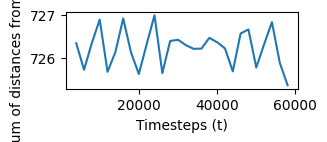

In [6]:
plt.figure(figsize=(3, 1))
plt.plot(t, all_dists)
plt.xlabel("Timesteps (t)")
plt.ylabel("Sum of distances from mean")
plt.savefig("all_dists_v2.svg")

In [7]:
mu = np.mean(all_dists)
std = np.std(all_dists)
mu, std

(726.2323, 0.41854146)

### Just to be sure, how stable is it after 60000 steps?

Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-0.033626147..1.0331798].


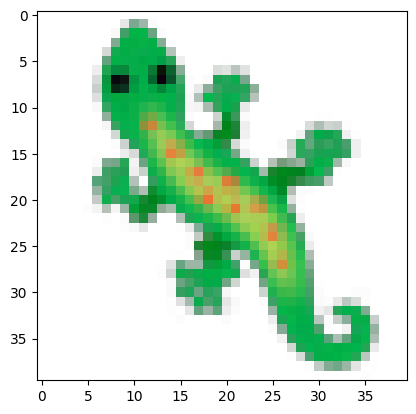

In [8]:
plt.imshow(states_np[-1,0,...,:4])

Pretty stable